In [1]:
import os
os.makedirs('flight_data', exist_ok=True)
print("Cartella creata!")


Cartella creata!


In [2]:
import requests
import time
import os

# Colonne che vogliamo scaricare
fields = [
    "Year", "Month", "DayofMonth", "DayOfWeek", "FlightDate",
    "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "OriginCityName", "OriginState",
    "Dest", "DestCityName", "DestState",
    "CRSDepTime", "DepTime", "DepDelay",
    "CRSArrTime", "ArrTime", "ArrDelay",
    "Cancelled", "CancellationCode",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay",
    "AirTime", "Distance"
]

base_url = "https://www.transtats.bts.gov/DownLoad_Table.asp"
output_dir = "flight_data"

for year in range(2003, 2026):
    for month in range(1, 13):
        # Salta mesi futuri
        if year == 2025 and month > 12:
            break
        
        filename = f"{output_dir}/{year}_{month:02d}.zip"
        
        # Salta se già scaricato
        if os.path.exists(filename):
            print(f"Già scaricato: {year}-{month:02d}")
            continue
        
        params = {
            "Table_ID": "236",
            "Has_Group": "3",
            "Is_Zipped": "0",
            "TIME_PERIOD": f"{year}{month:02d}",
        }
        
        # Aggiungi le colonne selezionate
        for field in fields:
            params[field] = field
        
        try:
            print(f"Scaricando {year}-{month:02d}...")
            response = requests.post(base_url, data=params, timeout=60)
            
            with open(filename, 'wb') as f:
                f.write(response.content)
            
            print(f"✅ Salvato: {filename} ({len(response.content)/1024:.0f} KB)")
            time.sleep(2)  # Pausa per non sovraccaricare il server
            
        except Exception as e:
            print(f"❌ Errore {year}-{month:02d}: {e}")

print("Download completato!")

Scaricando 2003-01...
✅ Salvato: flight_data/2003_01.zip (1 KB)
Scaricando 2003-02...
✅ Salvato: flight_data/2003_02.zip (1 KB)
Scaricando 2003-03...
✅ Salvato: flight_data/2003_03.zip (1 KB)
Scaricando 2003-04...
✅ Salvato: flight_data/2003_04.zip (1 KB)
Scaricando 2003-05...
✅ Salvato: flight_data/2003_05.zip (1 KB)
Scaricando 2003-06...
✅ Salvato: flight_data/2003_06.zip (1 KB)
Scaricando 2003-07...
✅ Salvato: flight_data/2003_07.zip (1 KB)
Scaricando 2003-08...
✅ Salvato: flight_data/2003_08.zip (1 KB)
Scaricando 2003-09...
✅ Salvato: flight_data/2003_09.zip (1 KB)
Scaricando 2003-10...
✅ Salvato: flight_data/2003_10.zip (1 KB)
Scaricando 2003-11...
✅ Salvato: flight_data/2003_11.zip (1 KB)
Scaricando 2003-12...
✅ Salvato: flight_data/2003_12.zip (1 KB)
Scaricando 2004-01...
✅ Salvato: flight_data/2004_01.zip (1 KB)
Scaricando 2004-02...
✅ Salvato: flight_data/2004_02.zip (1 KB)
Scaricando 2004-03...
✅ Salvato: flight_data/2004_03.zip (1 KB)
Scaricando 2004-04...
✅ Salvato: flight_

In [3]:
import os
import zipfile

output_dir = "flight_data"
files = os.listdir(output_dir)
print(f"Numero di file scaricati: {len(files)}")

# Verifica che i file siano zip validi
errori = []
for f in sorted(files):
    filepath = os.path.join(output_dir, f)
    try:
        with zipfile.ZipFile(filepath, 'r') as z:
            pass  # file valido
    except:
        errori.append(f)

if errori:
    print(f"\n❌ File corrotti o non validi ({len(errori)}):")
    for e in errori:
        print(f"  - {e}")
else:
    print("✅ Tutti i file sono zip validi!")
    

Numero di file scaricati: 276

❌ File corrotti o non validi (276):
  - 2003_01.zip
  - 2003_02.zip
  - 2003_03.zip
  - 2003_04.zip
  - 2003_05.zip
  - 2003_06.zip
  - 2003_07.zip
  - 2003_08.zip
  - 2003_09.zip
  - 2003_10.zip
  - 2003_11.zip
  - 2003_12.zip
  - 2004_01.zip
  - 2004_02.zip
  - 2004_03.zip
  - 2004_04.zip
  - 2004_05.zip
  - 2004_06.zip
  - 2004_07.zip
  - 2004_08.zip
  - 2004_09.zip
  - 2004_10.zip
  - 2004_11.zip
  - 2004_12.zip
  - 2005_01.zip
  - 2005_02.zip
  - 2005_03.zip
  - 2005_04.zip
  - 2005_05.zip
  - 2005_06.zip
  - 2005_07.zip
  - 2005_08.zip
  - 2005_09.zip
  - 2005_10.zip
  - 2005_11.zip
  - 2005_12.zip
  - 2006_01.zip
  - 2006_02.zip
  - 2006_03.zip
  - 2006_04.zip
  - 2006_05.zip
  - 2006_06.zip
  - 2006_07.zip
  - 2006_08.zip
  - 2006_09.zip
  - 2006_10.zip
  - 2006_11.zip
  - 2006_12.zip
  - 2007_01.zip
  - 2007_02.zip
  - 2007_03.zip
  - 2007_04.zip
  - 2007_05.zip
  - 2007_06.zip
  - 2007_07.zip
  - 2007_08.zip
  - 2007_09.zip
  - 2007_10.zip
  - 2

In [4]:
# Leggiamo il contenuto grezzo di un file per capire cosa ha risposto il server
with open("flight_data/2003_01.zip", 'rb') as f:
    content = f.read(500)
print(content)

b'<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">\r\n<html xmlns="http://www.w3.org/1999/xhtml">\r\n<head>\r\n<meta http-equiv="Content-Type" content="text/html; charset=iso-8859-1"/>\r\n<title>500 - Internal server error.</title>\r\n<style type="text/css">\r\n<!--\r\nbody{margin:0;font-size:.7em;font-family:Verdana, Arial, Helvetica, sans-serif;background:#EEEEEE;}\r\nfieldset{padding:0 15px 10px 15px;} \r\nh1{font-size:2.4em;margin:0;color:#FFF;}\r\nh2{f'


In [5]:
import os

folder = os.path.expanduser("~/Documents/flight_data")
files = sorted(os.listdir(folder))
print(f"Totale file: {len(files)}")
for f in files:
    size = os.path.getsize(os.path.join(folder, f)) / (1024*1024)
    print(f"{f} — {size:.1f} MB")

Totale file: 288
2003_01.zip — 0.0 MB
2003_02.zip — 0.0 MB
2003_03.zip — 0.0 MB
2003_04.zip — 0.0 MB
2003_05.zip — 0.0 MB
2003_06.zip — 0.0 MB
2003_07.zip — 0.0 MB
2003_08.zip — 0.0 MB
2003_09.zip — 0.0 MB
2003_10.zip — 0.0 MB
2003_11.zip — 0.0 MB
2003_12.zip — 0.0 MB
2004_01.zip — 0.0 MB
2004_02.zip — 0.0 MB
2004_03.zip — 0.0 MB
2004_04.zip — 0.0 MB
2004_05.zip — 0.0 MB
2004_06.zip — 0.0 MB
2004_07.zip — 0.0 MB
2004_08.zip — 0.0 MB
2004_09.zip — 0.0 MB
2004_10.zip — 0.0 MB
2004_11.zip — 0.0 MB
2004_12.zip — 0.0 MB
2005_01.zip — 0.0 MB
2005_02.zip — 0.0 MB
2005_03.zip — 0.0 MB
2005_04.zip — 0.0 MB
2005_05.zip — 0.0 MB
2005_06.zip — 0.0 MB
2005_07.zip — 0.0 MB
2005_08.zip — 0.0 MB
2005_09.zip — 0.0 MB
2005_10.zip — 0.0 MB
2005_11.zip — 0.0 MB
2005_12.zip — 0.0 MB
2006_01.zip — 0.0 MB
2006_02.zip — 0.0 MB
2006_03.zip — 0.0 MB
2006_04.zip — 0.0 MB
2006_05.zip — 0.0 MB
2006_06.zip — 0.0 MB
2006_07.zip — 0.0 MB
2006_08.zip — 0.0 MB
2006_09.zip — 0.0 MB
2006_10.zip — 0.0 MB
2006_11.zip — 0.0

In [6]:
import os

folder = os.path.expanduser("~/Documents/flight_data")
files = sorted(os.listdir(folder))

csv_files = [f for f in files if f.endswith('.csv')]
zip_files = [f for f in files if f.endswith('.zip')]
other = [f for f in files if not f.endswith('.csv') and not f.endswith('.zip')]

print(f"CSV: {len(csv_files)}")
print(f"ZIP: {len(zip_files)}")
print(f"Altri: {len(other)}")
print("\nFile CSV:")
for f in csv_files:
    size = os.path.getsize(os.path.join(folder, f)) / (1024*1024)
    print(f"  {f} — {size:.1f} MB")

CSV: 11
ZIP: 276
Altri: 1

File CSV:
  2009.csv — 755.9 MB
  2010.csv — 757.4 MB
  2011.csv — 712.3 MB
  2012.csv — 739.4 MB
  2013.csv — 751.0 MB
  2014.csv — 686.3 MB
  2015.csv — 685.8 MB
  2016.csv — 662.4 MB
  2017.csv — 669.7 MB
  2018.csv — 851.6 MB
  flights_sample_3m.csv — 585.7 MB


In [7]:
import os

folder = os.path.expanduser("~/Documents/flight_data")

# Elimina tutti i file zip
for f in os.listdir(folder):
    if f.endswith('.zip'):
        os.remove(os.path.join(folder, f))
        
print("ZIP eliminati!")

ZIP eliminati!


In [8]:
import os

folder = os.path.expanduser("~/Documents/flight_data")
files = sorted([f for f in os.listdir(folder) if f.endswith('.csv')])
print(f"Totale CSV: {len(files)}")
for f in files:
    size = os.path.getsize(os.path.join(folder, f)) / (1024*1024)
    print(f"  {f} — {size:.1f} MB")

Totale CSV: 18
  2009.csv — 755.9 MB
  2010.csv — 757.4 MB
  2011.csv — 712.3 MB
  2012.csv — 739.4 MB
  2013.csv — 751.0 MB
  2014.csv — 686.3 MB
  2015.csv — 685.8 MB
  2016.csv — 662.4 MB
  2017.csv — 669.7 MB
  2018.csv — 851.6 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2019_1.csv — 250.8 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2020_1.csv — 261.0 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2021_1.csv — 155.1 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv — 229.9 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_1.csv — 232.1 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv — 235.4 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_1.csv — 231.9 MB
  flights_sample_3m.csv — 585.7 MB


In [9]:
import pandas as pd

files_to_check = [
    "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2019_1.csv",
    "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2020_1.csv",
    "On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2021_1.csv",
]

folder = os.path.expanduser("~/Documents/flight_data")

for f in files_to_check:
    df = pd.read_csv(os.path.join(folder, f), nrows=5)
    print(f"\n{f[-10:]}")
    print(f"Colonne: {list(df.columns[:5])}")
    # Conta righe velocemente
    with open(os.path.join(folder, f)) as file:
        nrows = sum(1 for _ in file)
    print(f"Righe: {nrows:,}")


2019_1.csv
Colonne: ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek']
Righe: 583,986

2020_1.csv
Colonne: ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek']
Righe: 607,347

2021_1.csv
Colonne: ['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek']
Righe: 361,429


In [10]:
import requests
import os
import time

folder = os.path.expanduser("~/Documents/flight_data")

# Headers per simulare un browser reale
headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Referer': 'https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ&QO_fu146_anzr=b0-gvzr',
    'Origin': 'https://www.transtats.bts.gov',
    'Content-Type': 'application/x-www-form-urlencoded',
}

session = requests.Session()

# Prima facciamo una GET per ottenere i cookie e i campi nascosti
url = "https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ&QO_fu146_anzr=b0-gvzr"
response = session.get(url, headers=headers)
print(f"Status GET: {response.status_code}")
print("Cookie ottenuti:", dict(session.cookies))

Status GET: 200
Cookie ottenuti: {'ASP.NET_SessionId': 'co4oilu501v1qpcxiz3xbihm', 'f5avraaaaaaaaaaaaaaaa_session_': 'DHGHDOEGLMJGLBIDJCLCCIBIHOLHJOIOPEDDIMIMFCFPKLIDJBFCLFDDEJBKPCINIDCDOJHHOIONLHJDOMNADPFBKMIJGFFMGOGNDJPIJBAEEGKKNNOOCKHDHOEKBNNL'}


In [11]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, 'html.parser')

# Estrai i campi nascosti del form
hidden_fields = {}
for inp in soup.find_all('input', type='hidden'):
    if inp.get('name'):
        hidden_fields[inp['name']] = inp.get('value', '')

print(f"Campi nascosti trovati: {len(hidden_fields)}")
for k, v in list(hidden_fields.items())[:5]:
    print(f"  {k}: {v[:50] if v else ''}")

Campi nascosti trovati: 7
  affiliate: dot-bts
  __EVENTTARGET: 
  __EVENTARGUMENT: 
  __LASTFOCUS: 
  __VIEWSTATE: QKytyjWZgbDLALOc6lMvbqJrQR/+BM9Kw5O/58YTFeYmpiBClC


In [12]:
import zipfile
import io

def download_month(session, hidden_fields, year, month, folder, headers):
    
    # Campi del form
    form_data = hidden_fields.copy()
    form_data.update({
        'UserTableName': 'Reporting_Carrier_On_Time_Performance',
        'DBShortName': 'On_Time',
        'RawDataTable': 'T_ONTIME_REPORTING',
        'sqlstr': f'SELECT Year,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,OriginCityName,OriginState,Dest,DestCityName,DestState,CRSDepTime,DepTime,DepDelay,CRSArrTime,ArrTime,ArrDelay,Cancelled,CancellationCode,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,AirTime,Distance FROM T_ONTIME_REPORTING WHERE Month={month} AND YEAR={year}',
        'varlist': 'Year,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Flight_Number_Reporting_Airline,Origin,OriginCityName,OriginState,Dest,DestCityName,DestState,CRSDepTime,DepTime,DepDelay,CRSArrTime,ArrTime,ArrDelay,Cancelled,CancellationCode,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,AirTime,Distance',
        'groupby': '',
        'suml': '',
        'sumregion': '',
        'filter1': 'title=',
        'filter2': 'title=',
        'geo': 'All',
        'time': f'{year}/{month}',
        'timename': 'Month',
        'GEOGRAPHY': 'All',
        'ITYP': 'AllITYP',
        'BTNDownload': 'Download',
    })
    
    post_url = "https://www.transtats.bts.gov/DownLoad_Table.asp"
    response = session.post(post_url, data=form_data, headers=headers, timeout=120)
    
    filename = f"{folder}/{year}_{month:02d}.csv"
    
    # Prova a estrarre come zip
    try:
        z = zipfile.ZipFile(io.BytesIO(response.content))
        csv_name = z.namelist()[0]
        with open(filename, 'wb') as f:
            f.write(z.read(csv_name))
        size = os.path.getsize(filename) / (1024*1024)
        print(f"✅ {year}-{month:02d} salvato ({size:.1f} MB)")
        return True
    except Exception as e:
        print(f"❌ {year}-{month:02d} errore: {e}")
        print(f"   Risposta: {response.content[:200]}")
        return False

# Test con gennaio 2019
download_month(session, hidden_fields, 2019, 1, folder, headers)

❌ 2019-01 errore: File is not a zip file
   Risposta: b'<!DOCTYPE html PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">\r\n<html xmlns="http://www.w3.org/1999/xhtml">\r\n<head>\r\n<meta http-equiv="Content-Type" cont'


False

In [13]:
import os

folder = os.path.expanduser("~/Documents/flight_data")
files = sorted(os.listdir(folder))

csv_files = [f for f in files if f.endswith('.csv')]
parquet_files = [f for f in files if f.endswith('.parquet')]

print(f"CSV: {len(csv_files)}")
for f in csv_files:
    size = os.path.getsize(os.path.join(folder, f)) / (1024*1024)
    print(f"  {f} — {size:.1f} MB")

print(f"\nParquet: {len(parquet_files)}")
for f in parquet_files:
    size = os.path.getsize(os.path.join(folder, f)) / (1024*1024)
    print(f"  {f} — {size:.1f} MB")

CSV: 18
  2009.csv — 755.9 MB
  2010.csv — 757.4 MB
  2011.csv — 712.3 MB
  2012.csv — 739.4 MB
  2013.csv — 751.0 MB
  2014.csv — 686.3 MB
  2015.csv — 685.8 MB
  2016.csv — 662.4 MB
  2017.csv — 669.7 MB
  2018.csv — 851.6 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2019_1.csv — 250.8 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2020_1.csv — 261.0 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2021_1.csv — 155.1 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv — 229.9 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_1.csv — 232.1 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2024_1.csv — 235.4 MB
  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_1.csv — 231.9 MB
  flights_sample_3m.csv — 585.7 MB

Parquet: 0


In [14]:
cd ~/Documents/flight_data && for f in Combined_Flights_*.zip; do unzip -o "$f"; done

[Errno 2] No such file or directory: '/Users/riccardolangella/Documents/flight_data && for f in Combined_Flights_*.zip; do unzip -o flights_sample_3m.csv; done'
/Users/riccardolangella/Documents


In [15]:
import os
import pandas as pd

folder = os.path.expanduser("~/Documents/flight_data")
parquet_files = sorted([f for f in os.listdir(folder) if f.endswith('.parquet')])

print(f"Parquet: {len(parquet_files)}")
for f in parquet_files:
    size = os.path.getsize(os.path.join(folder, f)) / (1024*1024)
    df = pd.read_parquet(os.path.join(folder, f), engine='pyarrow')
    print(f"  {f} — {size:.1f} MB — {len(df):,} righe — colonne: {list(df.columns[:5])}")

Parquet: 4
  Combined_Flights_2019.parquet — 294.4 MB — 8,091,684 righe — colonne: ['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled']
  Combined_Flights_2020.parquet — 174.6 MB — 5,022,397 righe — colonne: ['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled']
  Combined_Flights_2021.parquet — 231.7 MB — 6,311,871 righe — colonne: ['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled']
  Combined_Flights_2022.parquet — 142.7 MB — 4,078,318 righe — colonne: ['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled']


In [16]:
# Controlla colonne parquet vs CSV
df_parquet = pd.read_parquet(os.path.join(folder, 'Combined_Flights_2019.parquet'))
df_csv = pd.read_csv(os.path.join(folder, '2018.csv'), nrows=5)

print("Colonne PARQUET (2019-2022):")
print(list(df_parquet.columns))

print("\nColonne CSV (2009-2018):")
print(list(df_csv.columns))

Colonne PARQUET (2019-2022):
['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted', 'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime', 'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrDelay', 'Ar

In [17]:
import pandas as pd
import os
import gc

folder = os.path.expanduser("~/Documents/flight_data")

# Colonne comuni che vogliamo tenere
def process_csv(filepath):
    df = pd.read_csv(filepath, low_memory=False)
    df = df.rename(columns={
        'FL_DATE': 'FlightDate',
        'OP_CARRIER': 'Airline',
        'ORIGIN': 'Origin',
        'DEST': 'Dest',
        'CRS_DEP_TIME': 'CRSDepTime',
        'DEP_TIME': 'DepTime',
        'DEP_DELAY': 'DepDelay',
        'CRS_ARR_TIME': 'CRSArrTime',
        'ARR_TIME': 'ArrTime',
        'ARR_DELAY': 'ArrDelay',
        'CANCELLED': 'Cancelled',
        'CANCELLATION_CODE': 'CancellationCode',
        'DIVERTED': 'Diverted',
        'AIR_TIME': 'AirTime',
        'DISTANCE': 'Distance',
        'CARRIER_DELAY': 'CarrierDelay',
        'WEATHER_DELAY': 'WeatherDelay',
        'NAS_DELAY': 'NASDelay',
        'SECURITY_DELAY': 'SecurityDelay',
        'LATE_AIRCRAFT_DELAY': 'LateAircraftDelay',
    })
    df['FlightDate'] = pd.to_datetime(df['FlightDate'])
    df['Year'] = df['FlightDate'].dt.year
    df['Month'] = df['FlightDate'].dt.month
    df['DayofMonth'] = df['FlightDate'].dt.day
    return df

def process_parquet(filepath):
    df = pd.read_parquet(filepath)
    df['FlightDate'] = pd.to_datetime(df['FlightDate'])
    return df

# Colonne finali comuni
COLS = ['FlightDate', 'Year', 'Month', 'DayofMonth', 'Airline',
        'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay',
        'CRSArrTime', 'ArrTime', 'ArrDelay', 'Cancelled', 'Diverted',
        'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay',
        'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

all_dfs = []

# Carica CSV 2009-2018
for year in range(2009, 2019):
    print(f"Caricando {year}.csv...")
    df = process_csv(os.path.join(folder, f'{year}.csv'))
    # Tieni solo colonne disponibili
    cols = [c for c in COLS if c in df.columns]
    all_dfs.append(df[cols])
    gc.collect()

# Carica Parquet 2019-2022
for year in range(2019, 2023):
    print(f"Caricando Combined_Flights_{year}.parquet...")
    df = process_parquet(os.path.join(folder, f'Combined_Flights_{year}.parquet'))
    cols = [c for c in COLS if c in df.columns]
    all_dfs.append(df[cols])
    gc.collect()

print("\nUnendo tutti i dataset...")
df_all = pd.concat(all_dfs, ignore_index=True)
print(f"✅ Dataset completo: {len(df_all):,} righe, {len(df_all.columns)} colonne")
print(f"Anni coperti: {df_all['Year'].min()} - {df_all['Year'].max()}")

Caricando 2009.csv...
Caricando 2010.csv...
Caricando 2011.csv...
Caricando 2012.csv...
Caricando 2013.csv...
Caricando 2014.csv...
Caricando 2015.csv...
Caricando 2016.csv...
Caricando 2017.csv...
Caricando 2018.csv...
Caricando Combined_Flights_2019.parquet...
Caricando Combined_Flights_2020.parquet...
Caricando Combined_Flights_2021.parquet...
Caricando Combined_Flights_2022.parquet...

Unendo tutti i dataset...
✅ Dataset completo: 85,061,234 righe, 22 colonne
Anni coperti: 2009 - 2022


In [18]:
output_path = os.path.join(folder, 'flights_2009_2022.parquet')
print("Salvando il dataset unificato...")
df_all.to_parquet(output_path, index=False, engine='pyarrow')
size = os.path.getsize(output_path) / (1024*1024*1024)
print(f"✅ Salvato: {output_path}")
print(f"   Dimensione: {size:.2f} GB")

Salvando il dataset unificato...
✅ Salvato: /Users/riccardolangella/Documents/flight_data/flights_2009_2022.parquet
   Dimensione: 1.05 GB


In [19]:
# Panoramica generale
print("=== PANORAMICA DATASET ===")
print(f"Righe totali: {len(df_all):,}")
print(f"Colonne: {list(df_all.columns)}")
print(f"\nAnni: {df_all['Year'].min()} - {df_all['Year'].max()}")
print(f"\nVoli per anno:")
print(df_all.groupby('Year').size().to_string())

print(f"\nValori mancanti per colonna:")
print(df_all.isnull().sum().to_string())

print(f"\nStatistiche ritardi:")
print(df_all[['DepDelay', 'ArrDelay']].describe())

print(f"\nTasso cancellazioni: {df_all['Cancelled'].mean()*100:.2f}%")

=== PANORAMICA DATASET ===
Righe totali: 85,061,234
Colonne: ['FlightDate', 'Year', 'Month', 'DayofMonth', 'Airline', 'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'Cancelled', 'Diverted', 'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

Anni: 2009 - 2022

Voli per anno:
Year
2009    6429338
2010    6450117
2011    6066650
2012    6096762
2013    6369482
2014    5819811
2015    5819079
2016    5617658
2017    5674621
2018    7213446
2019    8091684
2020    5022397
2021    6311871
2022    4078318

Valori mancanti per colonna:
FlightDate                  0
Year                        0
Month                       0
DayofMonth                  0
Airline                     0
Origin                      0
Dest                        0
CRSDepTime                  1
DepTime               1611995
DepDelay              1617184
CRSArrTime                  2
ArrTime               1692577
ArrDel

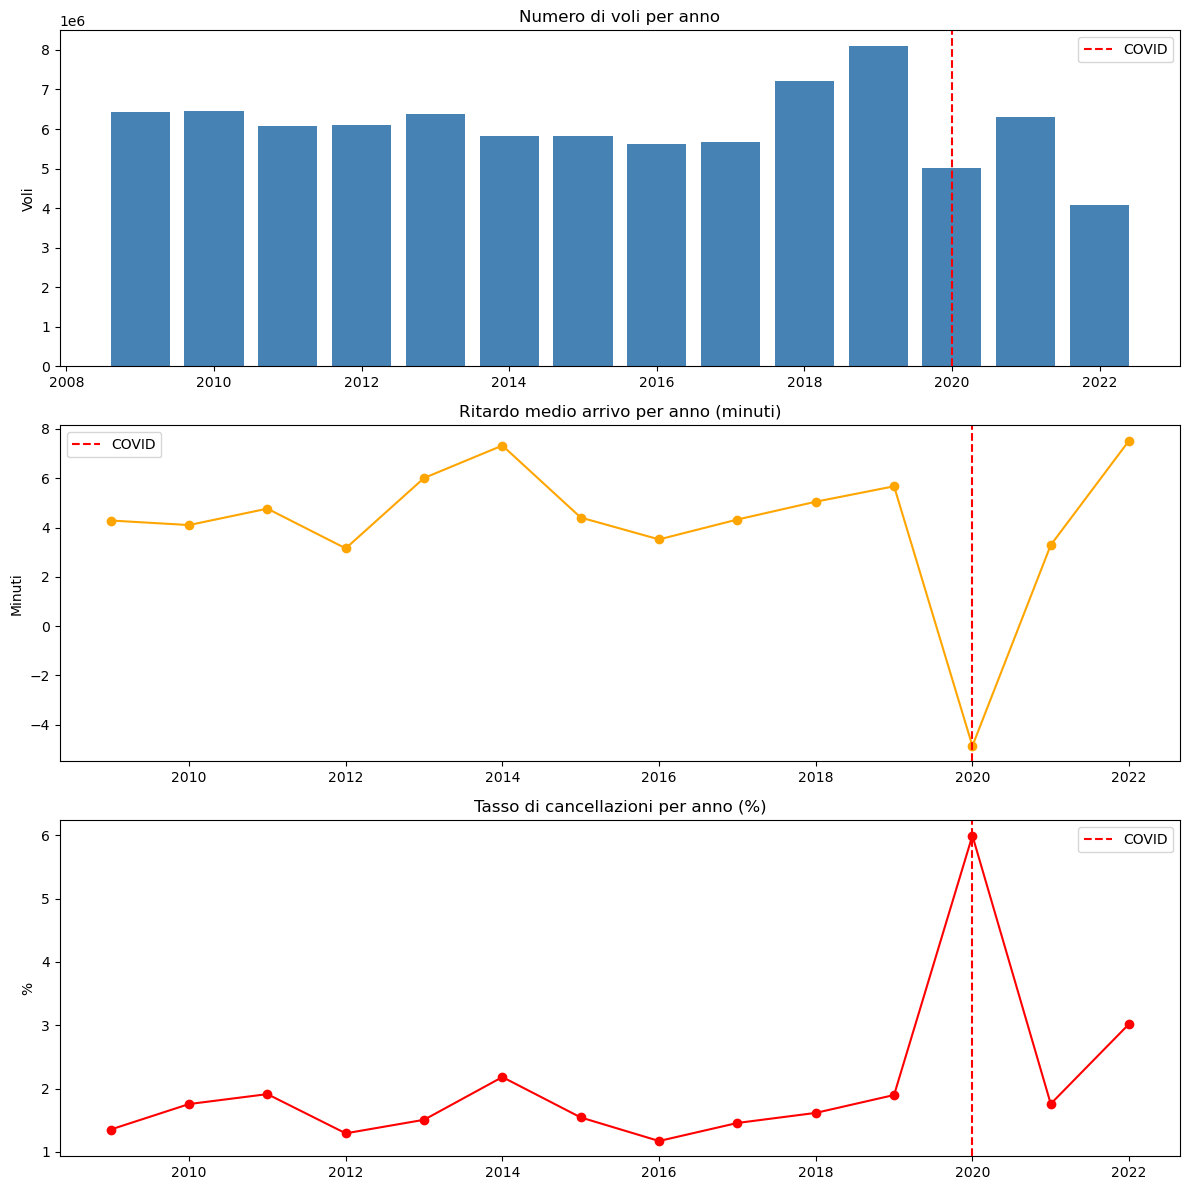

✅ Grafico salvato!


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# 1. Voli per anno
yearly = df_all.groupby('Year').size()
axes[0].bar(yearly.index, yearly.values, color='steelblue')
axes[0].set_title('Numero di voli per anno')
axes[0].set_ylabel('Voli')
axes[0].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[0].legend()

# 2. Ritardo medio per anno
yearly_delay = df_all.groupby('Year')['ArrDelay'].mean()
axes[1].plot(yearly_delay.index, yearly_delay.values, marker='o', color='orange')
axes[1].set_title('Ritardo medio arrivo per anno (minuti)')
axes[1].set_ylabel('Minuti')
axes[1].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[1].legend()

# 3. Tasso cancellazioni per anno
yearly_cancel = df_all.groupby('Year')['Cancelled'].mean() * 100
axes[2].plot(yearly_cancel.index, yearly_cancel.values, marker='o', color='red')
axes[2].set_title('Tasso di cancellazioni per anno (%)')
axes[2].set_ylabel('%')
axes[2].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(folder, 'overview.png'), dpi=150)
plt.show()
print("✅ Grafico salvato!")

In [21]:
print("Dimensioni prima della pulizia:", df_all.shape)

# Rimuovi outlier estremi (ritardi > 24 ore sono quasi certamente errori)
df_clean = df_all[
    (df_all['DepDelay'].isna()) | (df_all['DepDelay'].between(-120, 1440))
].copy()

# Per le cause di ritardo, i NaN significano "nessun ritardo" → sostituisci con 0
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
df_clean[delay_cols] = df_clean[delay_cols].fillna(0)

print("Dimensioni dopo la pulizia:", df_clean.shape)
print(f"Righe rimosse: {len(df_all) - len(df_clean):,}")

Dimensioni prima della pulizia: (85061234, 22)
Dimensioni dopo la pulizia: (85060091, 22)
Righe rimosse: 1,143


In [22]:
# Feature engineering
df_clean['IsDelayed'] = (df_clean['ArrDelay'] > 15).astype(int)  # ritardo > 15 min = in ritardo
df_clean['IsWeekend'] = df_clean['DayOfWeek'].isin([6, 7]).astype(int) if 'DayOfWeek' in df_clean.columns else 0
df_clean['DepHour'] = (df_clean['CRSDepTime'] // 100).astype(int)  # ora di partenza
df_clean['Season'] = df_clean['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

print("Nuove features create:")
print(f"  Voli in ritardo (>15 min): {df_clean['IsDelayed'].sum():,} ({df_clean['IsDelayed'].mean()*100:.1f}%)")
print(f"\nRitardi per stagione:")
print(df_clean.groupby('Season')['IsDelayed'].mean().sort_values(ascending=False) * 100)
print(f"\nRitardi per ora di partenza:")
print(df_clean.groupby('DepHour')['IsDelayed'].mean().sort_values(ascending=False).head(5) * 100)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [23]:
df_clean['IsDelayed'] = (df_clean['ArrDelay'] > 15).astype(int)
df_clean['IsWeekend'] = df_clean['DayOfWeek'].isin([6, 7]).astype(int) if 'DayOfWeek' in df_clean.columns else 0
df_clean['DepHour'] = (df_clean['CRSDepTime'] // 100).fillna(-1).astype(int)
df_clean['Season'] = df_clean['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

print("Nuove features create:")
print(f"  Voli in ritardo (>15 min): {df_clean['IsDelayed'].sum():,} ({df_clean['IsDelayed'].mean()*100:.1f}%)")
print(f"\nRitardi per stagione:")
print(df_clean.groupby('Season')['IsDelayed'].mean().sort_values(ascending=False) * 100)
print(f"\nRitardi per ora di partenza (top 5 peggiori):")
print(df_clean.groupby('DepHour')['IsDelayed'].mean().sort_values(ascending=False).head(5) * 100)

Nuove features create:
  Voli in ritardo (>15 min): 14,732,110 (17.3%)

Ritardi per stagione:
Season
Summer    20.266017
Winter    18.237775
Spring    16.610624
Fall      13.838389
Name: IsDelayed, dtype: float64

Ritardi per ora di partenza (top 5 peggiori):
DepHour
-1     100.000000
 19     24.244632
 20     24.236020
 18     24.056785
 21     23.150249
Name: IsDelayed, dtype: float64


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Sample 1M rows for training
print("Creating sample for ML...")
df_sample = df_clean[df_clean['ArrDelay'].notna()].sample(n=1_000_000, random_state=42)

# Encode airline as numeric code
df_sample['Airline_code'] = df_sample['Airline'].astype('category').cat.codes

# Define features and target variable
features = ['Month', 'DayofMonth', 'DepHour', 'IsWeekend', 'Distance', 'Airline_code']
X = df_sample[features].fillna(-1)
y = df_sample['IsDelayed']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train):,} rows")
print(f"Test set: {len(X_test):,} rows")

# Train Logistic Regression model
print("\nTraining Logistic Regression...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

Creating sample for ML...
Training set: 800,000 rows
Test set: 200,000 rows

Training Logistic Regression...

Accuracy: 82.3%

Detailed report:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90    164622
           1       0.00      0.00      0.00     35378

    accuracy                           0.82    200000
   macro avg       0.41      0.50      0.45    200000
weighted avg       0.68      0.82      0.74    200000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Sample 1M rows for training
print("Creating sample for ML...")
df_sample = df_clean[df_clean['ArrDelay'].notna()].sample(n=1_000_000, random_state=42)

# Encode airline as numeric code
df_sample['Airline_code'] = df_sample['Airline'].astype('category').cat.codes

# Define features and target variable
features = ['Month', 'DayofMonth', 'DepHour', 'IsWeekend', 'Distance', 'Airline_code']
X = df_sample[features].fillna(-1)
y = df_sample['IsDelayed']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calculate class imbalance ratio
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {scale:.1f}")

# Train XGBoost with class balancing
print("\nTraining XGBoost...")
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale,  # handles class imbalance
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

ModuleNotFoundError: No module named 'xgboost'

In [26]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Sample 1M rows for training
print("Creating sample for ML...")
df_sample = df_clean[df_clean['ArrDelay'].notna()].sample(n=1_000_000, random_state=42)

# Encode airline as numeric code
df_sample['Airline_code'] = df_sample['Airline'].astype('category').cat.codes

# Define features and target variable
features = ['Month', 'DayofMonth', 'DepHour', 'IsWeekend', 'Distance', 'Airline_code']
X = df_sample[features].fillna(-1)
y = df_sample['IsDelayed']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calculate class imbalance ratio
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {scale:.1f}")

# Train XGBoost with class balancing
print("\nTraining XGBoost...")
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale,  # handles class imbalance
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

Creating sample for ML...
Class imbalance ratio: 4.7

Training XGBoost...

Accuracy: 60.4%

Detailed report:
              precision    recall  f1-score   support

           0       0.88      0.60      0.71    164622
           1       0.25      0.61      0.35     35378

    accuracy                           0.60    200000
   macro avg       0.56      0.61      0.53    200000
weighted avg       0.77      0.60      0.65    200000



In [27]:
# Add route as a feature
df_sample['Route'] = df_sample['Origin'] + '_' + df_sample['Dest']
df_sample['Route_code'] = df_sample['Route'].astype('category').cat.codes
df_sample['Origin_code'] = df_sample['Origin'].astype('category').cat.codes
df_sample['Dest_code'] = df_sample['Dest'].astype('category').cat.codes

# Extended feature set
features = ['Month', 'DayofMonth', 'DepHour', 'IsWeekend', 
            'Distance', 'Airline_code', 'Origin_code', 'Dest_code', 'Route_code']

X = df_sample[features].fillna(-1)
y = df_sample['IsDelayed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scale = (y_train == 0).sum() / (y_train == 1).sum()

print("Training XGBoost with extended features...")
model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

# Feature importance
import pandas as pd
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance.to_string(index=False))

Training XGBoost with extended features...

Accuracy: 62.4%

Detailed report:
              precision    recall  f1-score   support

           0       0.88      0.63      0.73    164622
           1       0.26      0.60      0.36     35378

    accuracy                           0.62    200000
   macro avg       0.57      0.61      0.55    200000
weighted avg       0.77      0.62      0.67    200000


Feature Importance:
     Feature  Importance
     DepHour    0.291273
Airline_code    0.136534
       Month    0.126822
   Dest_code    0.100601
  Route_code    0.097094
 Origin_code    0.090791
    Distance    0.084635
  DayofMonth    0.072250
   IsWeekend    0.000000


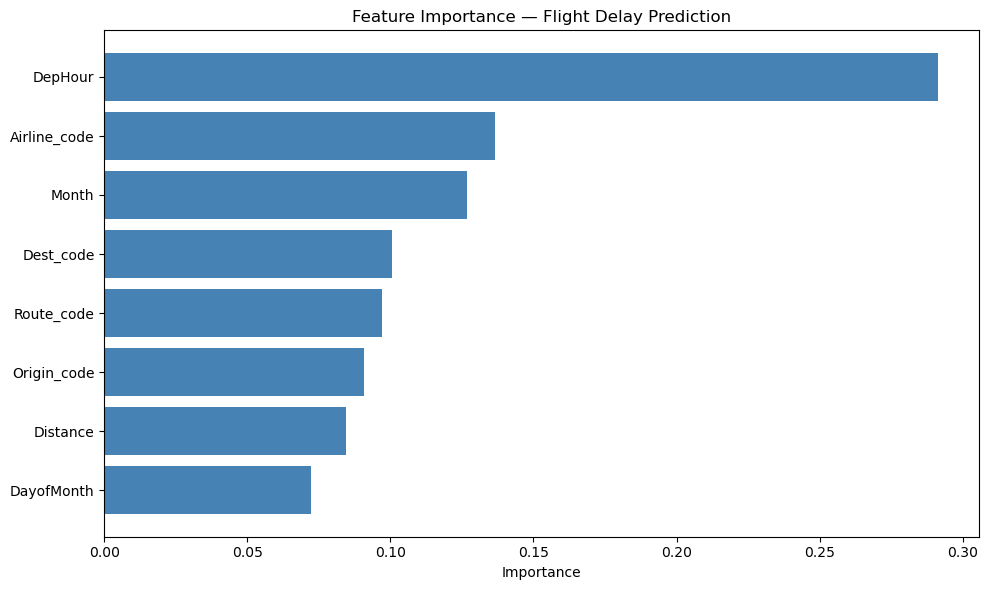


=== PREDICTION EXAMPLE ===
Question: Will a Delta flight departing at 8pm in July
from JFK to LAX (2475 miles) be delayed?

Delay probability: 64.3%
Prediction: ⚠️ DELAYED


In [28]:
import matplotlib.pyplot as plt

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 6))
importance_filtered = importance[importance['Feature'] != 'IsWeekend']
ax.barh(importance_filtered['Feature'], importance_filtered['Importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance — Flight Delay Prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(folder, 'feature_importance.png'), dpi=150)
plt.show()

# Concrete prediction example
print("\n=== PREDICTION EXAMPLE ===")
print("Question: Will a Delta flight departing at 8pm in July")
print("from JFK to LAX (2475 miles) be delayed?\n")

airline_map = dict(zip(df_sample['Airline'], df_sample['Airline_code']))
origin_map = dict(zip(df_sample['Origin'], df_sample['Origin_code']))
dest_map = dict(zip(df_sample['Dest'], df_sample['Dest_code']))
route_map = dict(zip(df_sample['Route'], df_sample['Route_code']))

example = pd.DataFrame([{
    'Month': 7,
    'DayofMonth': 15,
    'DepHour': 20,
    'IsWeekend': 0,
    'Distance': 2475,
    'Airline_code': airline_map.get('DL', 0),
    'Origin_code': origin_map.get('JFK', 0),
    'Dest_code': dest_map.get('LAX', 0),
    'Route_code': route_map.get('JFK_LAX', 0),
}])

prob = model.predict_proba(example)[0][1]
pred = model.predict(example)[0]
print(f"Delay probability: {prob*100:.1f}%")
print(f"Prediction: {'⚠️ DELAYED' if pred == 1 else '✅ ON TIME'}")

In [29]:
# Compute historical delay rate per airline, route and hour
print("Computing historical features...")

# Average delay rate per airline
airline_delay = df_clean.groupby('Airline')['IsDelayed'].mean().rename('Airline_delay_rate')

# Average delay rate per route
df_clean['Route'] = df_clean['Origin'] + '_' + df_clean['Dest']
route_delay = df_clean.groupby('Route')['IsDelayed'].mean().rename('Route_delay_rate')

# Average delay rate per departure hour
hour_delay = df_clean.groupby('DepHour')['IsDelayed'].mean().rename('Hour_delay_rate')

# Average delay rate per month
month_delay = df_clean.groupby('Month')['IsDelayed'].mean().rename('Month_delay_rate')

# Merge historical features into sample
df_sample['Route'] = df_sample['Origin'] + '_' + df_sample['Dest']
df_sample = df_sample.join(airline_delay, on='Airline')
df_sample = df_sample.join(route_delay, on='Route')
df_sample = df_sample.join(hour_delay, on='DepHour')
df_sample = df_sample.join(month_delay, on='Month')

print("Historical features added:")
print(df_sample[['Airline_delay_rate', 'Route_delay_rate', 
                  'Hour_delay_rate', 'Month_delay_rate']].describe())

Computing historical features...
Historical features added:
       Airline_delay_rate  Route_delay_rate  Hour_delay_rate  Month_delay_rate
count      1000000.000000    1000000.000000   1000000.000000    1000000.000000
mean             0.173099          0.172990         0.173172          0.173153
std              0.027037          0.040272         0.052401          0.025301
min              0.079198          0.000000         0.072381          0.134066
25%              0.158810          0.146492         0.130111          0.161312
50%              0.174257          0.171249         0.178119          0.173681
75%              0.187171          0.198344         0.228482          0.201096
max              0.367707          1.000000         0.242446          0.212373


In [30]:
# Extended feature set with historical rates
features = ['Month', 'DayofMonth', 'DepHour', 'Distance', 
            'Airline_code', 'Origin_code', 'Dest_code', 'Route_code',
            'Airline_delay_rate', 'Route_delay_rate', 
            'Hour_delay_rate', 'Month_delay_rate']

X = df_sample[features].fillna(-1)
y = df_sample['IsDelayed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scale = (y_train == 0).sum() / (y_train == 1).sum()

print("Training improved XGBoost...")
model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

# Updated feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance.to_string(index=False))

Training improved XGBoost...

Accuracy: 62.7%

Detailed report:
              precision    recall  f1-score   support

           0       0.88      0.63      0.74    164622
           1       0.26      0.60      0.36     35378

    accuracy                           0.63    200000
   macro avg       0.57      0.62      0.55    200000
weighted avg       0.77      0.63      0.67    200000


Feature Importance:
           Feature  Importance
   Hour_delay_rate    0.353006
  Route_delay_rate    0.105565
  Month_delay_rate    0.086071
           DepHour    0.085494
Airline_delay_rate    0.071835
      Airline_code    0.051582
             Month    0.047351
        Route_code    0.044055
          Distance    0.040847
         Dest_code    0.040614
       Origin_code    0.037212
        DayofMonth    0.036369


In [31]:
import pickle

# Save the trained model and encoders
print("Saving model and encoders...")

model_data = {
    'model': model,
    'features': features,
    'airline_map': airline_map,
    'origin_map': origin_map,
    'dest_map': dest_map,
    'route_map': route_map,
    'airline_delay': airline_delay,
    'route_delay': route_delay,
    'hour_delay': hour_delay,
    'month_delay': month_delay,
}

with open(os.path.join(folder, 'flight_delay_model.pkl'), 'wb') as f:
    pickle.dump(model_data, f)

size = os.path.getsize(os.path.join(folder, 'flight_delay_model.pkl')) / (1024*1024)
print(f"✅ Model saved! Size: {size:.1f} MB")

Saving model and encoders...
✅ Model saved! Size: 3.1 MB


In [32]:
# Train cancellation prediction model
print("Training cancellation prediction model...")

# Use same sample but predict Cancelled instead of IsDelayed
X_cancel = df_sample[features].fillna(-1)
y_cancel = df_sample['Cancelled']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancel, y_cancel, test_size=0.2, random_state=42)

# Class imbalance for cancellations (~2%)
scale_cancel = (y_train_c == 0).sum() / (y_train_c == 1).sum()
print(f"Cancellation class imbalance ratio: {scale_cancel:.1f}")

model_cancel = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=scale_cancel,
    random_state=42,
    eval_metric='logloss'
)
model_cancel.fit(X_train_c, y_train_c)

y_pred_c = model_cancel.predict(X_test_c)
print(f"\nAccuracy: {accuracy_score(y_test_c, y_pred_c)*100:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test_c, y_pred_c))

Training cancellation prediction model...
Cancellation class imbalance ratio: inf


/var/folders/bl/shm9dwbj565g6gc6jmzt2f2m0000gn/T/ipykernel_43731/4037249830.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  scale_cancel = (y_train_c == 0).sum() / (y_train_c == 1).sum()



Accuracy: 100.0%

Detailed report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    200000

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000



In [33]:
# Build balanced sample with cancellations
print("Building balanced sample for cancellation model...")

# Take all cancelled flights
cancelled = df_clean[df_clean['Cancelled'] == 1]
not_cancelled = df_clean[df_clean['Cancelled'] == 0].sample(n=len(cancelled)*4, random_state=42)

df_cancel_sample = pd.concat([cancelled, not_cancelled]).sample(frac=1, random_state=42)
print(f"Cancelled flights: {len(cancelled):,}")
print(f"Not cancelled flights: {len(not_cancelled):,}")
print(f"Total sample: {len(df_cancel_sample):,}")

# Add route and historical features
df_cancel_sample['Route'] = df_cancel_sample['Origin'] + '_' + df_cancel_sample['Dest']
df_cancel_sample['Airline_code'] = df_cancel_sample['Airline'].astype('category').cat.codes
df_cancel_sample['Route_code'] = df_cancel_sample['Route'].astype('category').cat.codes
df_cancel_sample['Origin_code'] = df_cancel_sample['Origin'].astype('category').cat.codes
df_cancel_sample['Dest_code'] = df_cancel_sample['Dest'].astype('category').cat.codes
df_cancel_sample = df_cancel_sample.join(airline_delay, on='Airline')
df_cancel_sample = df_cancel_sample.join(route_delay, on='Route')
df_cancel_sample = df_cancel_sample.join(hour_delay, on='DepHour')
df_cancel_sample = df_cancel_sample.join(month_delay, on='Month')

X_cancel = df_cancel_sample[features].fillna(-1)
y_cancel = df_cancel_sample['Cancelled']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancel, y_cancel, test_size=0.2, random_state=42)

print("\nTraining cancellation model...")
model_cancel = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model_cancel.fit(X_train_c, y_train_c)

y_pred_c = model_cancel.predict(X_test_c)
print(f"\nAccuracy: {accuracy_score(y_test_c, y_pred_c)*100:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test_c, y_pred_c))


Building balanced sample for cancellation model...
Cancelled flights: 1,662,096
Not cancelled flights: 6,648,384
Total sample: 8,310,480

Training cancellation model...

Accuracy: 82.4%

Detailed report:
              precision    recall  f1-score   support

         0.0       0.84      0.97      0.90   1330153
         1.0       0.66      0.24      0.35    331943

    accuracy                           0.82   1662096
   macro avg       0.75      0.61      0.63   1662096
weighted avg       0.80      0.82      0.79   1662096



In [34]:
# Save cancellation model
model_data['model_cancel'] = model_cancel

with open(os.path.join(folder, 'flight_delay_model.pkl'), 'wb') as f:
    pickle.dump(model_data, f)

print("✅ Cancellation model saved!")

✅ Cancellation model saved!


In [35]:
app_code = '''
import streamlit as st
import pickle
import pandas as pd
import numpy as np

# Load model
with open('flight_delay_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

model = model_data['model']
model_cancel = model_data['model_cancel']
features = model_data['features']
airline_map = model_data['airline_map']
origin_map = model_data['origin_map']
dest_map = model_data['dest_map']
route_map = model_data['route_map']
airline_delay = model_data['airline_delay']
route_delay = model_data['route_delay']
hour_delay = model_data['hour_delay']
month_delay = model_data['month_delay']

# App title
st.title("✈️ Flight Delay & Cancellation Predictor")
st.markdown("Predict whether your flight will be delayed or cancelled based on historical US flight data (2009-2022)")

# Input form
st.sidebar.header("Flight Details")

airline = st.sidebar.selectbox("Airline", sorted(airline_map.keys()))
origin = st.sidebar.selectbox("Origin Airport", sorted(origin_map.keys()))
dest = st.sidebar.selectbox("Destination Airport", sorted(dest_map.keys()))
month = st.sidebar.slider("Month", 1, 12, 7)
day = st.sidebar.slider("Day of Month", 1, 31, 15)
hour = st.sidebar.slider("Departure Hour", 0, 23, 8)
distance = st.sidebar.number_input("Distance (miles)", min_value=50, max_value=5000, value=500)

month_names = {1:"January",2:"February",3:"March",4:"April",5:"May",6:"June",
               7:"July",8:"August",9:"September",10:"October",11:"November",12:"December"}

if st.sidebar.button("Predict", type="primary"):
    route = f"{origin}_{dest}"
    
    input_data = pd.DataFrame([{
        'Month': month,
        'DayofMonth': day,
        'DepHour': hour,
        'Distance': distance,
        'Airline_code': airline_map.get(airline, 0),
        'Origin_code': origin_map.get(origin, 0),
        'Dest_code': dest_map.get(dest, 0),
        'Route_code': route_map.get(route, 0),
        'Airline_delay_rate': airline_delay.get(airline, 0.17),
        'Route_delay_rate': route_delay.get(route, 0.17),
        'Hour_delay_rate': hour_delay.get(hour, 0.17),
        'Month_delay_rate': month_delay.get(month, 0.17),
    }])
    
    delay_prob = model.predict_proba(input_data)[0][1]
    cancel_prob = model_cancel.predict_proba(input_data)[0][1]
    
    st.subheader(f"Results for {airline}: {origin} → {dest}")
    st.write(f"📅 {month_names[month]} {day}, departing at {hour}:00")
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.metric("Delay Probability", f"{delay_prob*100:.1f}%")
        if delay_prob > 0.5:
            st.error("⚠️ High risk of delay (>15 min)")
        elif delay_prob > 0.3:
            st.warning("🟡 Moderate risk of delay")
        else:
            st.success("✅ Low risk of delay")
    
    with col2:
        st.metric("Cancellation Probability", f"{cancel_prob*100:.1f}%")
        if cancel_prob > 0.1:
            st.error("⚠️ High risk of cancellation")
        elif cancel_prob > 0.05:
            st.warning("🟡 Moderate risk of cancellation")
        else:
            st.success("✅ Low risk of cancellation")
    
    # Historical stats
    st.subheader("📊 Historical Statistics")
    col3, col4, col5 = st.columns(3)
    with col3:
        st.metric("Airline avg delay rate", f"{airline_delay.get(airline, 0)*100:.1f}%")
    with col4:
        st.metric("Route avg delay rate", f"{route_delay.get(route, 0)*100:.1f}%")
    with col5:
        st.metric("Hour avg delay rate", f"{hour_delay.get(hour, 0)*100:.1f}%")
'''

with open(os.path.expanduser('~/Documents/flight_data/app.py'), 'w') as f:
    f.write(app_code)

print("✅ app.py created!")

✅ app.py created!
